## 
1. Imports
2. Load Preprocessed Dataset
3. Train-Test Split
4. Build Preprocessing Pipeline
5. Train Logistic Regression (Baseline)
6. Evaluate
7. Train Decision Tree
8. Train Random Forest
9. Compare Models
10. Save Best Model

## Import 

In [4]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

## Load dataset 

In [6]:
df = pd.read_csv("../data/processed/preprocessed_data.csv")

## Quick Check

In [8]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [10]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Seperate Feature & Target 

In [12]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

## Train test split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

## Identify Feature type

In [16]:
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()

numerical_cols = X_train.select_dtypes(exclude="object").columns.tolist()

print(categorical_cols)
print(numerical_cols)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges']
['SeniorCitizen', 'tenure', 'MonthlyCharges']


## Building th eprocessing pipeline

In [18]:
numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

## Logistic regression Pipeline

In [20]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=RANDOM_STATE))
])

### Train

In [22]:
logistic_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod',
                                                   'TotalCharges'])])),
                ('classifier', LogisticRegression(random_state=42))])

### Predict

In [24]:
y_pred = logistic_pipeline.predict(X_test)

y_prob = logistic_pipeline.predict_proba(X_test)[:,1]

### Evauluation 

In [26]:
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")

print(f"Precision: {precision_score(y_test, y_pred):.4f}")

print(f"Recall   : {recall_score(y_test, y_pred):.4f}")

print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")

print(f"ROC AUC  : {roc_auc_score(y_test, y_prob):.4f}")

Accuracy : 0.7942
Precision: 0.6312
Recall   : 0.5401
F1 Score : 0.5821
ROC AUC  : 0.8403


### Classification report 

In [28]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



### Confusion matrix

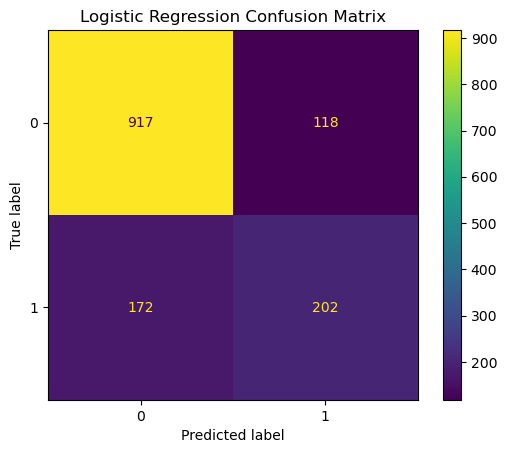

In [30]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

### ROC Curve

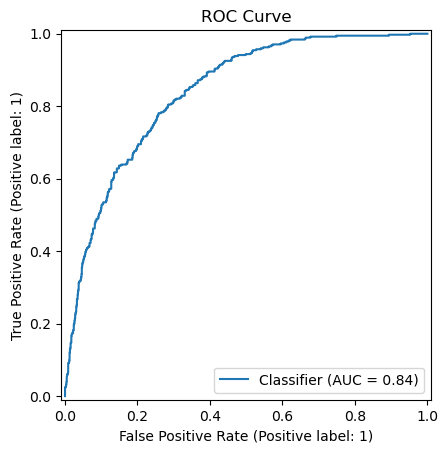

In [32]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("ROC Curve")
plt.show()

In [33]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

## Create model Dictionary

In [35]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    "LightGBM": LGBMClassifier(
        random_state=42
    )
}

## Creating reusable evaluation function

In [37]:
results = []

for model_name, classifier in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", classifier)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

    print("=" * 60)
    print(model_name)
    print(classification_report(y_test, y_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409

Decision Tree
              precision    recall  f1-score   support

           0       0.83      0.86      0.85      1035
           1       0.58      0.53      0.55       374

    accuracy                           0.78      1409
   macro avg       0.71      0.70      0.70      1409
weighted avg       0.77      0.78      0.77      1409

Random Forest
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1035
           1       0.62      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.70      1409
weighted avg       0.77   

## Compare Model

In [40]:
results_df = (
    pd.DataFrame(results)
      .sort_values(
          by="ROC-AUC",
          ascending=False
      )
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.794180,0.631250,0.540107,0.582133,0.840298
4,LightGBM,0.794890,0.639344,0.521390,0.574374,0.835729
2,Random Forest,0.782825,0.621429,0.465241,0.532110,0.820652
3,XGBoost,0.782825,0.605590,0.521390,0.560345,0.818697
1,Decision Tree,0.775018,0.584570,0.526738,0.554149,0.696254


## Visual Comparison

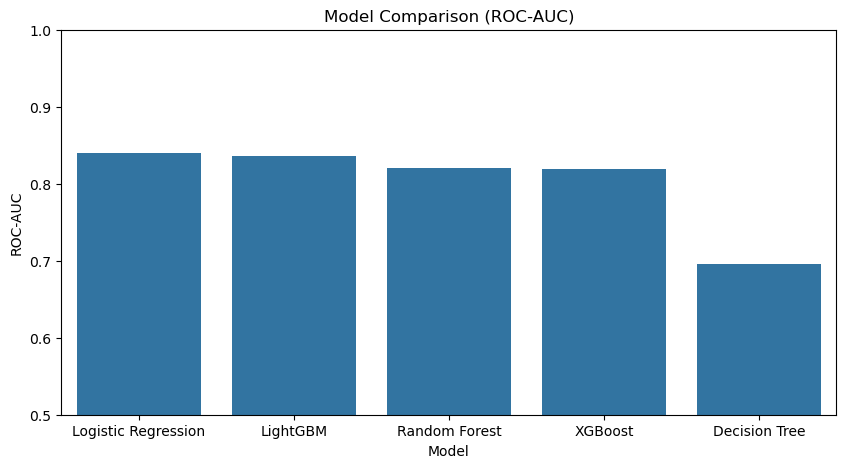

In [43]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="ROC-AUC"
)

plt.title("Model Comparison (ROC-AUC)")
plt.ylim(0.5, 1.0)
plt.show()

## ROC curve together

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000363 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 414
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328


<Figure size 800x600 with 0 Axes>

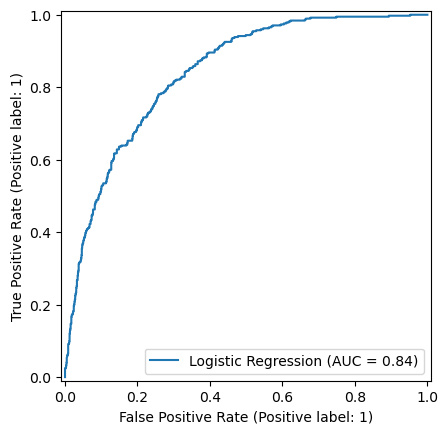

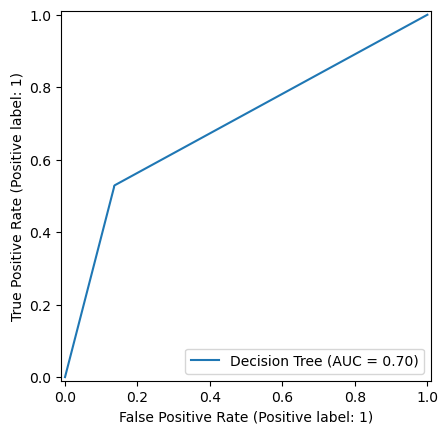

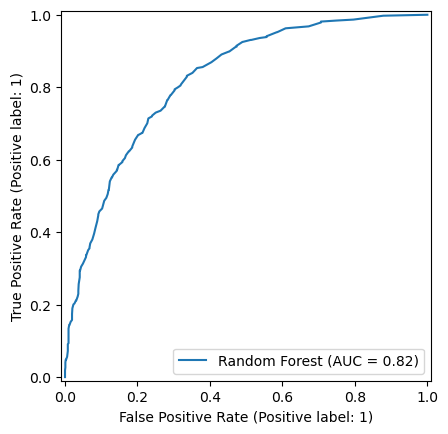

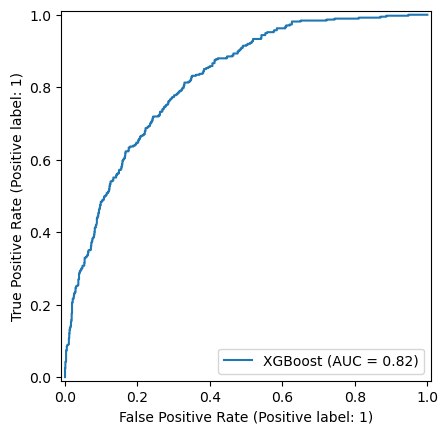

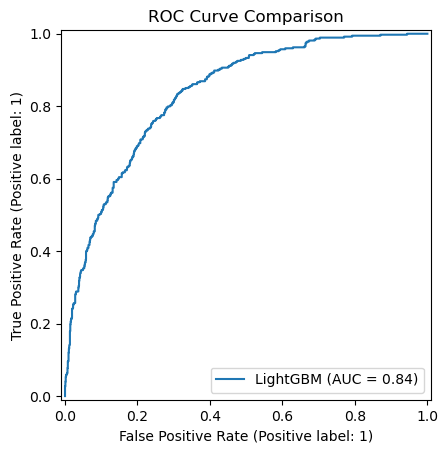

In [46]:
plt.figure(figsize=(8,6))

for model_name, classifier in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", classifier)
    ])

    pipeline.fit(X_train, y_train)

    RocCurveDisplay.from_estimator(
        pipeline,
        X_test,
        y_test,
        name=model_name
    )

plt.title("ROC Curve Comparison")
plt.show()

## Confusion matrix

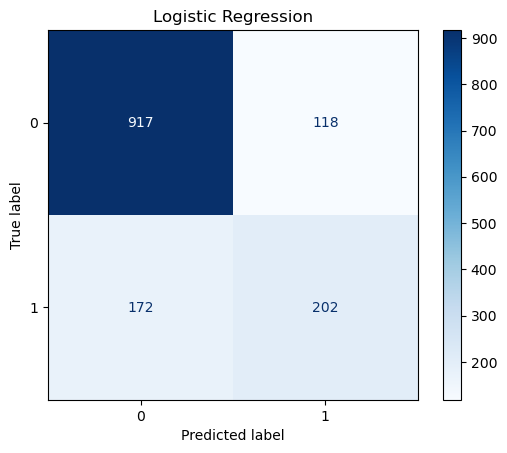

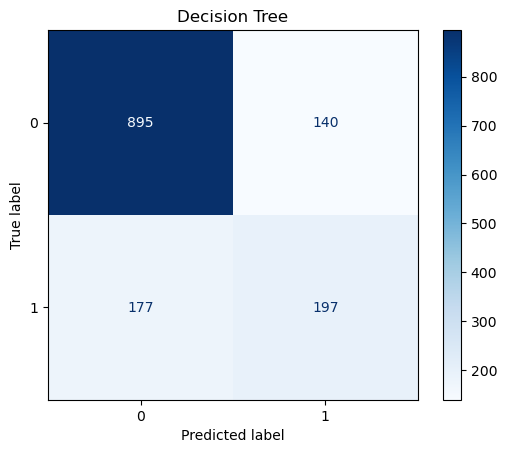

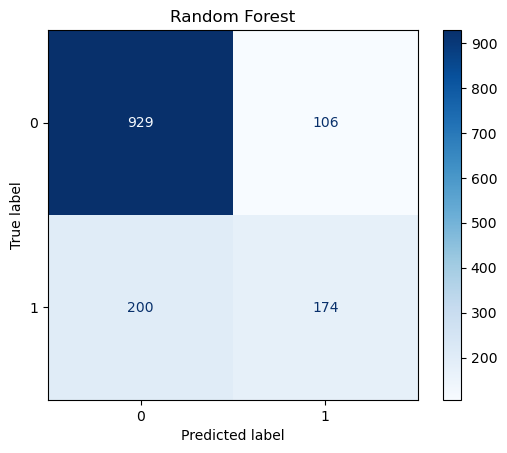

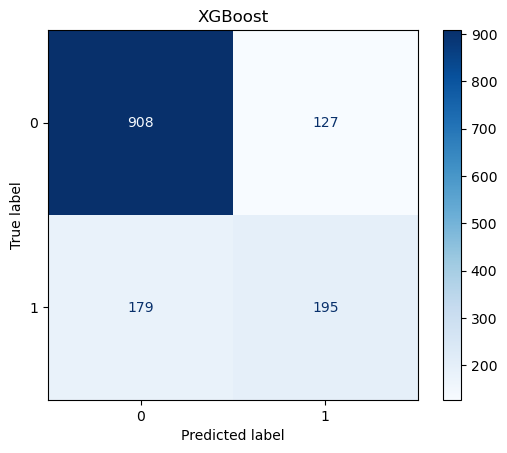

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000674 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 414
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328


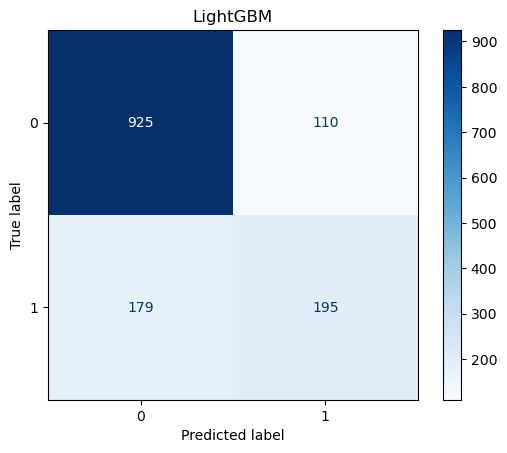

In [49]:
for model_name, classifier in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", classifier)
    ])

    pipeline.fit(X_train, y_train)

    ConfusionMatrixDisplay.from_estimator(
        pipeline,
        X_test,
        y_test,
        cmap="Blues"
    )

    plt.title(model_name)
    plt.show()

In [51]:
best_model_name = results_df.iloc[0]["Model"]

print(best_model_name)

Logistic Regression


In [53]:
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.794180,0.631250,0.540107,0.582133,0.840298
4,LightGBM,0.794890,0.639344,0.521390,0.574374,0.835729
2,Random Forest,0.782825,0.621429,0.465241,0.532110,0.820652
3,XGBoost,0.782825,0.605590,0.521390,0.560345,0.818697
1,Decision Tree,0.775018,0.584570,0.526738,0.554149,0.696254


### Model Selection

Customer churn is an imbalanced classification problem. While accuracy is useful, it can be misleading because the majority class ("No Churn") dominates the dataset.

Therefore, ROC-AUC is used as the primary evaluation metric since it measures how well the model distinguishes between churn and non-churn customers across all classification thresholds.

Based on ROC-AUC, Logistic Regression achieved the best performance among the baseline models.